<a href="https://colab.research.google.com/github/thanakppm/Project_Python_Retail_Store_Group_4/blob/main/Retail_Store.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Project Python Retail Store Group 4

```
683020241-0 นางสาวณัฏฐ์ปรัศมน ทวีโภควรกุล
683020250-9 นางสาวนรมณ พวงศรีเคน
683020563-8 นางสาวกฤษณา กาลิง
683020572-7 นายธนากร พงษ์เพชร
683020589-0 นางสาวพัชริญา ภูโนนทา
```

# Import

In [1]:
import datetime
import pandas as pd
import sqlite3
import matplotlib, os, shutil
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# ฟอนต์ไทย
!apt-get -y install fonts-thai-tlwg
cache_dir = matplotlib.get_cachedir()
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)
font_path = '/usr/share/fonts/truetype/tlwg/Loma.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'Loma'
plt.rcParams['axes.unicode_minus'] = False

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-tlwg-garuda fonts-tlwg-garuda-ttf fonts-tlwg-kinnari
  fonts-tlwg-kinnari-ttf fonts-tlwg-laksaman fonts-tlwg-laksaman-ttf
  fonts-tlwg-loma fonts-tlwg-loma-ttf fonts-tlwg-mono fonts-tlwg-mono-ttf
  fonts-tlwg-norasi fonts-tlwg-norasi-ttf fonts-tlwg-purisa
  fonts-tlwg-purisa-ttf fonts-tlwg-sawasdee fonts-tlwg-sawasdee-ttf
  fonts-tlwg-typewriter fonts-tlwg-typewriter-ttf fonts-tlwg-typist
  fonts-tlwg-typist-ttf fonts-tlwg-typo fonts-tlwg-typo-ttf fonts-tlwg-umpush
  fonts-tlwg-umpush-ttf fonts-tlwg-waree fonts-tlwg-waree-ttf
The following NEW packages will be installed:
  fonts-thai-tlwg fonts-tlwg-garuda fonts-tlwg-garuda-ttf fonts-tlwg-kinnari
  fonts-tlwg-kinnari-ttf fonts-tlwg-laksaman fonts-tlwg-laksaman-ttf
  fonts-tlwg-loma fonts-tlwg-loma-ttf fonts-tlwg-mono fonts-tlwg-mono-ttf
  fonts-tlwg-norasi fonts-tlwg-norasi-ttf fo

## Classes: Customer, Product, Inventory, Order, DailyReport

In [2]:
import random
from datetime import datetime, timedelta

# ============================================================
# Custom Exceptions (Error Handling)
# ============================================================

class RetailError(Exception):
    """คลาสแม่ของ Error ทั้งหมดในระบบร้านค้าปลีก"""
    pass


class InvalidQuantityError(RetailError):
    """เกิดขึ้นเมื่อจำนวนสินค้าที่ระบุไม่ถูกต้อง (เช่น <= 0)"""
    pass


class ProductNotFoundError(RetailError):
    """เกิดขึ้นเมื่อหาสินค้านั้นไม่พบใน Inventory"""
    pass


class InsufficientStockError(RetailError):
    """เกิดขึ้นเมื่อสินค้าใน Stock ไม่พอสำหรับคำขอ"""
    pass


class OrderAlreadyPaidError(RetailError):
    """เกิดขึ้นเมื่อพยายามแก้ไข/ชำระเงินซ้ำ Order ที่จ่ายแล้ว"""
    pass


class InsufficientPointsError(RetailError):
    """เกิดขึ้นเมื่อลูกค้าพยายามใช้คะแนนมากกว่าที่มีอยู่"""
    pass


# ============================================================
# Class: Customer
# ============================================================

class Customer:

    POINTS_PER_BAHT = 10

    def __init__(self, customer_id, name, is_member=False, points=0): #เก็บข้อมูลของลูกค้า
        self.customer_id = customer_id
        self.name = name
        self.is_member = is_member
        self.points = points

    def add_points(self, points): #เพิ่มคะแนน
        if self.is_member:
            self.points += points

    def redeem_points(self, points_to_use): #ใช้คะแนน
        if not self.is_member:
            raise InsufficientPointsError(
                f"{self.name} ไม่ได้เป็นสมาชิก ไม่สามารถใช้คะแนนได้"
            )

        if points_to_use <= 0:
            raise InvalidQuantityError("จำนวนคะแนนที่ต้องการใช้ต้องมากกว่า 0")

        if points_to_use > self.points:
            raise InsufficientPointsError(
                f"{self.name} มีคะแนนไม่พอ "
                f"(มี {self.points} คะแนน, ต้องการใช้ {points_to_use} คะแนน)"
            )

        # ปัดให้ใช้เป็นจำนวนเต็มสิบเท่านั้น (เศษที่ไม่ครบ 10 จะไม่ถูกใช้)
        usable_points = points_to_use - (points_to_use % self.POINTS_PER_BAHT)

        if usable_points <= 0:
            raise InvalidQuantityError(
                "จำนวนคะแนนต้องอย่างน้อย 10 คะแนน ถึงจะแลกส่วนลดได้"
            )

        discount = usable_points / self.POINTS_PER_BAHT

        self.points -= usable_points

        return usable_points, discount

    def customer_info(self): #แสดงข้อมูลของลูกค้า
        return {
            "customer_id": self.customer_id,
            "name": self.name,
            "is_member": self.is_member,
            "points": self.points
        }


# ============================================================
# Class: Product
# ============================================================

class Product:

    def __init__(self, product_id, name, category, cost, price): #เก็บข้อมูลสินค้า
        self.product_id = product_id
        self.name = name
        self.category = category
        self.cost = cost
        self.price = price

    def get_profit_per_unit(self): #กำไรต่อหน่วย = ราคาขาย - ต้นทุน
        return self.price - self.cost

    def product_info(self): #แสดงข้อมูลของสินค้า
        return {
            "product_id": self.product_id,
            "name": self.name,
            "category": self.category,
            "cost": self.cost,
            "price": self.price,
            "profit": self.get_profit_per_unit()
        }


# ============================================================
# Class: Inventory
# ============================================================

class Inventory:

    def __init__(self):
        self.stock = {}

    def add_product(
        self,
        product,
        shelf=0,
        warehouse=0,
        shelf_min=5,
        warehouse_min=10
    ):
        self.stock[product.product_id] = {
            "product": product,
            "shelf": shelf,
            "warehouse": warehouse,
            "shelf_min": shelf_min,
            "warehouse_min": warehouse_min
        }

    def _get_item(self, product):
        # Helper ภายใน: ตรวจสอบว่ามีสินค้านี้ใน Inventory หรือไม่
        # ถ้าไม่มี ให้ raise ProductNotFoundError ทันที
        if product.product_id not in self.stock:
            raise ProductNotFoundError(
                f"ไม่พบสินค้า '{product.name}' ใน Inventory"
            )
        return self.stock[product.product_id]

    def restock_shelf(self, product, quantity):
        # ย้ายสินค้าจาก Warehouse มาเติมที่ Shelf

        if quantity <= 0:
            raise InvalidQuantityError("จำนวนสินค้าต้องมากกว่า 0")

        item = self._get_item(product)

        if item["warehouse"] < quantity:
            raise InsufficientStockError(
                f"สินค้าในโกดังของ {product.name} ไม่เพียงพอสำหรับเติมชั้น"
            )

        item["warehouse"] -= quantity
        item["shelf"] += quantity

        print(f"เติม {product.name} จำนวน {quantity} ชิ้น จาก Warehouse -> Shelf")

        return True

    def sell_product(self, product, quantity):
        # ตัดสินค้าออกจาก Shelf เมื่อชำระเงินเรียบร้อยแล้ว

        if quantity <= 0:
            raise InvalidQuantityError("จำนวนสินค้าต้องมากกว่า 0")

        item = self._get_item(product)

        if item["shelf"] < quantity:
            raise InsufficientStockError(
                f"สินค้า {product.name} บนชั้นวางไม่เพียงพอ"
            )

        item["shelf"] -= quantity

        return True

    def can_sell(self, product, quantity):
        # ตรวจสอบ Stock ก่อนการขายจริง (คืนค่า True/False ไม่ raise error
        # เพราะเป็นแค่การ "เช็คเงื่อนไข" ไม่ใช่การเปลี่ยนแปลงข้อมูล)

        if quantity <= 0:
            return False

        if product.product_id not in self.stock:
            return False

        return self.stock[product.product_id]["shelf"] >= quantity

    def adjust_stock(self, product, shelf=None, warehouse=None):
        # ปรับ Stock กรณีตรวจนับสินค้าจริงแล้วไม่ตรงกับระบบ

        item = self._get_item(product)

        if shelf is not None and shelf < 0:
            raise InvalidQuantityError("จำนวนสินค้า Shelf ไม่สามารถติดลบได้")

        if warehouse is not None and warehouse < 0:
            raise InvalidQuantityError("จำนวนสินค้า Warehouse ไม่สามารถติดลบได้")

        if shelf is not None:
            item["shelf"] = shelf

        if warehouse is not None:
            item["warehouse"] = warehouse

        return True

    def check_alert(self):
        alerts = []

        for item in self.stock.values():
            product = item["product"]

            if item["shelf"] <= item["shelf_min"]:
                alerts.append(
                    f"[แจ้งเตือน] {product.name}: Shelf เหลือ {item['shelf']} ชิ้น ควรเติมสินค้า"
                )

            if item["warehouse"] <= item["warehouse_min"]:
                alerts.append(
                    f"[แจ้งเตือน] {product.name}: Warehouse เหลือ {item['warehouse']} ชิ้น ควรสั่งสินค้าเพิ่ม"
                )

        return alerts

    def receive_stock(self, product, quantity):
        # จำลองกรณีร้านได้รับสินค้าใหม่เข้า Warehouse

        if quantity <= 0:
            raise InvalidQuantityError("จำนวนสินค้าต้องมากกว่า 0")

        item = self._get_item(product)

        item["warehouse"] += quantity

        print(f"รับสินค้า {product.name} เข้า Warehouse จำนวน {quantity} ชิ้น")

        return True

    def show_stock(self, product):
        item = self._get_item(product)

        print(f"\nสินค้า: {product.name}")
        print(f"Shelf: {item['shelf']} ชิ้น")
        print(f"Warehouse: {item['warehouse']} ชิ้น")


# ============================================================
# Class: Order
# ============================================================

class Order:
    def __init__(self, order_id, customer, inventory, order_time=None):
        self.order_id = order_id
        self.customer = customer
        self.inventory = inventory
        self.items = []
        self.total = 0
        self.discount = 0
        self.points_used = 0
        self.points_earned = 0
        self.is_paid = False
        self.order_time = order_time

    def add_product(self, product, quantity):

        if self.is_paid:
            raise OrderAlreadyPaidError(
                f"Order {self.order_id} ชำระเงินแล้ว ไม่สามารถเพิ่มสินค้าได้"
            )

        if quantity <= 0:
            raise InvalidQuantityError("จำนวนสินค้าต้องมากกว่า 0")

        if product.product_id not in self.inventory.stock:
            raise ProductNotFoundError(f"ไม่พบสินค้า '{product.name}' ใน Inventory")

        current_quantity = 0
        for item in self.items:
            if item["product"].product_id == product.product_id:
                current_quantity += item["quantity"]

        if not self.inventory.can_sell(product, current_quantity + quantity):
            raise InsufficientStockError(
                f"สินค้า {product.name} บน Shelf ไม่เพียงพอสำหรับ Order นี้"
            )

        for item in self.items:
            if item["product"].product_id == product.product_id:
                item["quantity"] += quantity
                self.total += product.price * quantity
                return True

        self.items.append({"product": product, "quantity": quantity})
        self.total += product.price * quantity

        return True

    def remove_product(self, product):
        if self.is_paid:
            raise OrderAlreadyPaidError(
                f"Order {self.order_id} ชำระเงินแล้ว ไม่สามารถแก้ไขได้"
            )

        for item in self.items:
            if item["product"].product_id == product.product_id:
                self.total -= item["product"].price * item["quantity"]
                self.items.remove(item)
                return True

        raise ProductNotFoundError(f"ไม่พบสินค้า '{product.name}' ใน Order นี้")

    def apply_points(self, points_to_use):
        # ใช้คะแนนสมาชิกแลกส่วนลดก่อนชำระเงิน
        # ต้องเรียกก่อน pay() เท่านั้น

        if self.is_paid:
            raise OrderAlreadyPaidError(
                f"Order {self.order_id} ชำระเงินแล้ว ไม่สามารถใช้คะแนนเพิ่มได้"
            )

        usable_points, discount = self.customer.redeem_points(points_to_use)

        # ส่วนลดต้องไม่เกินยอดซื้อ (กันกรณีคะแนนเยอะกว่ายอดซื้อมาก)
        discount = min(discount, self.total - self.discount)

        self.discount += discount
        self.points_used += usable_points

        print(
            f"Order {self.order_id} ใช้คะแนน {usable_points} คะแนน "
            f"แลกส่วนลด {discount:.2f} บาท"
        )

        return True

    def pay(self):
        # 1. ตรวจสอบว่ายังไม่จ่าย
        # 2. ตรวจสอบ Stock ของสินค้าทุกตัวก่อน (กันตัด Stock ไปครึ่งทาง)
        # 3. ตัด Stock จริง
        # 4. คำนวณคะแนนที่ได้รับ (คิดจากยอดสุทธิหลังหักส่วนลด)

        if self.is_paid:
            raise OrderAlreadyPaidError(f"Order {self.order_id} ชำระเงินไปแล้ว")

        if len(self.items) == 0:
            raise InvalidQuantityError(f"Order {self.order_id} ไม่มีสินค้า")

        for item in self.items:
            product = item["product"]
            quantity = item["quantity"]
            if not self.inventory.can_sell(product, quantity):
                raise InsufficientStockError(
                    f"ไม่สามารถชำระเงินได้ เพราะสินค้า {product.name} ไม่เพียงพอ"
                )

        for item in self.items:
            self.inventory.sell_product(item["product"], item["quantity"])

        self.is_paid = True

        # ยอดสุทธิหลังหักส่วนลดจากคะแนน
        net_total = max(self.total - self.discount, 0)

        # คำนวณคะแนนสมาชิกใหม่ที่ได้รับ: ทุก 50 บาท (ของยอดสุทธิ) = 1 คะแนน
        points = int(net_total // 50)
        self.customer.add_points(points)
        self.points_earned = points

        print(
            f"ชำระเงิน Order {self.order_id} สำเร็จ "
            f"ยอดรวม {self.total:.2f} บาท ส่วนลด {self.discount:.2f} บาท "
            f"ยอดสุทธิ {net_total:.2f} บาท "
            f"(ได้รับ {points} คะแนน)"
        )

        return True

    def show_bill(self):
        net_total = max(self.total - self.discount, 0)

        print("\n" + "=" * 40)
        print(f"Order ID: {self.order_id}")
        print(f"Customer: {self.customer.name}"
              + (" (สมาชิก)" if self.customer.is_member else ""))
        print("=" * 40)

        for item in self.items:
            product = item["product"]
            quantity = item["quantity"]
            subtotal = product.price * quantity
            print(f"{product.name} x {quantity} = {subtotal:.2f} บาท")

        print("-" * 40)
        print(f"ยอดรวม: {self.total:.2f} บาท")

        if self.discount > 0:
            print(f"ส่วนลดจากคะแนนสมาชิก (-{self.points_used} คะแนน): -{self.discount:.2f} บาท")

        print(f"ยอดสุทธิ: {net_total:.2f} บาท")

        if self.is_paid:
            print(f"สถานะ: ชำระเงินแล้ว (ได้รับ {self.points_earned} คะแนน)")
        else:
            print("สถานะ: ยังไม่ชำระเงิน")

        print("=" * 40)


# ============================================================
# Class: DailyReport
# ============================================================

class DailyReport:

    def __init__(self, orders, report_date):
        self.orders = orders
        self.report_date = report_date

    def get_paid_orders(self):
        paid_orders = []
        for order in self.orders:
            if order.order_time is None:
                continue
            order_date = order.order_time.strftime("%Y-%m-%d")
            if order.is_paid and order_date == self.report_date:
                paid_orders.append(order)
        return paid_orders

    def summary(self):
        paid_orders = self.get_paid_orders()
        total_sales = sum(order.total - order.discount for order in paid_orders)
        total_cost = 0
        total_items = 0

        for order in paid_orders:
            for item in order.items:
                product = item["product"]
                quantity = item["quantity"]
                total_cost += product.cost * quantity
                total_items += quantity

        total_profit = total_sales - total_cost

        return {
            "report_date": self.report_date,
            "total_orders": len(paid_orders),
            "total_items": total_items,
            "total_sales": total_sales,
            "total_cost": total_cost,
            "total_profit": total_profit
        }

    def show_summary(self):
        result = self.summary()
        print("\n" + "=" * 40)
        print(f"รายงานยอดขายประจำวันที่ {result['report_date']}")
        print("=" * 40)
        print(f"จำนวน Order: {result['total_orders']}")
        print(f"จำนวนสินค้าที่ขาย: {result['total_items']} ชิ้น")
        print(f"ยอดขายรวม: {result['total_sales']:.2f} บาท")
        print(f"ต้นทุนรวม: {result['total_cost']:.2f} บาท")
        print(f"กำไรรวม: {result['total_profit']:.2f} บาท")
        print("=" * 40)




# Simulation

## 1) เตรียมข้อมูล: สินค้า 3 หมวด (ขนม / เครื่องดื่ม / ของใช้), Inventory, ลูกค้า


In [3]:
# ============================================================
# 1. สร้างรายการสินค้า แบ่งเป็น 3 หมวด (ของทั่วไปในร้านค้าปลีก)
# ============================================================

products = []

snack_names = [
    "มันฝรั่งทอด", "ขนมปังกรอบ", "ช็อกโกแลต", "เวเฟอร์", "คุกกี้",
    "ข้าวเกรียบ", "เยลลี่", "ถั่วอบ", "ขนมแท่ง", "เค้ก",
]
for i, name in enumerate(snack_names, start=1):
    cost = random.randint(8, 20)
    price = cost + random.randint(5, 15)
    products.append(Product(f"S{i:02d}", name, "ขนม", cost, price))

drink_names = [
    "น้ำดื่ม", "น้ำแร่", "น้ำอัดลม", "ชาเขียว", "เครื่องดื่มวิตามิน",
    "กาแฟกระป๋อง", "นมถั่วเหลือง", "น้ำผลไม้",
]
for i, name in enumerate(drink_names, start=1):
    cost = random.randint(5, 15)
    price = cost + random.randint(5, 10)
    products.append(Product(f"D{i:02d}", name, "เครื่องดื่ม", cost, price))

household_names = [
    "สบู่ก้อน", "แชมพู", "ยาสีฟัน", "กระดาษทิชชู่", "ผงซักฟอก",
    "น้ำยาล้างจาน", "ถ่านไฟฉาย",
]
for i, name in enumerate(household_names, start=1):
    cost = random.randint(15, 40)
    price = cost + random.randint(10, 25)
    products.append(Product(f"H{i:02d}", name, "ของใช้", cost, price))

print(f"สร้างสินค้าทั้งหมด {len(products)} ชนิด")
print(f"- ขนม {len(snack_names)} ชนิด, เครื่องดื่ม {len(drink_names)} ชนิด, ของใช้ {len(household_names)} ชนิด")

# ============================================================
# 2. เพิ่มสินค้าทั้งหมดเข้าสู่ Inventory
# ============================================================

inventory = Inventory()
for product in products:
    inventory.add_product(
        product=product,
        shelf=random.randint(20, 40),
        warehouse=random.randint(30, 60),
        shelf_min=5,
        warehouse_min=10
    )

# ============================================================
# 3. สร้างลูกค้า
# ============================================================

customers = []
for i in range(1, 51):
    is_member = random.choice([True, False])
    points = random.randint(0, 100) if is_member else 0
    customers.append(Customer(f"C{i:03d}", f"ลูกค้า {i}", is_member, points))


สร้างสินค้าทั้งหมด 25 ชนิด
- ขนม 10 ชนิด, เครื่องดื่ม 8 ชนิด, ของใช้ 7 ชนิด


## 2) Demo: เล่าเหตุการณ์ลูกค้า 1 คนเดินเข้าร้าน (ก่อนเข้าสู่ Simulation จริง)

ส่วนนี้จำลองลูกค้า 1 คนแบบ step-by-step — หยิบสินค้า, ดูรายการก่อนจ่ายเงิน, ใช้แต้มสมาชิกแลกส่วนลด, จ่ายเงิน และดูใบเสร็จ — เพื่อให้เห็นว่า Object และ Method ที่ออกแบบไว้ทำงานร่วมกันอย่างไรในเหตุการณ์จริง 1 ครั้ง ก่อนจะรัน Simulation ทีละ 300+ รายการ


In [4]:
# ============================================================
# Demo: เล่าเหตุการณ์ลูกค้า 1 คนเดินเข้าร้าน (แบบ Step-by-step)
# ============================================================
# ส่วนนี้ไม่ใช่ Simulation หลัก แต่เป็นตัวอย่างสาธิตให้เห็นว่า
# object และ method ที่ออกแบบไว้ทำงานร่วมกันอย่างไรในเหตุการณ์จริง 1 ครั้ง
# ============================================================

print("\n" + "#" * 60)
print("DEMO: จำลองลูกค้า 1 คนเดินเข้าร้าน")
print("#" * 60)

demo_customer = customers[0]
demo_customer.is_member = True
demo_customer.points = 45
print(f"\n[ก้าวที่ 1] คุณ {demo_customer.name} เดินเข้าร้าน "
      f"(สถานะ: {'สมาชิก' if demo_customer.is_member else 'ลูกค้าทั่วไป'}, "
      f"แต้มสะสม {demo_customer.points} คะแนน)")

demo_order = Order(
    order_id="DEMO0001",
    customer=demo_customer,
    inventory=inventory,
    order_time=datetime(2026, 8, 15, 18, 30)
)

print("\n[ก้าวที่ 2] เดินไปหยิบสินค้าใส่ตะกร้า...")

pick_list = [(products[0], 2), (products[10], 1), (products[20], 1)]
for product, qty in pick_list:
    demo_order.add_product(product, qty)
    print(f"  -> หยิบ {product.name} จำนวน {qty} ชิ้น ใส่ตะกร้าแล้ว")

print("\n[ก้าวที่ 3] เดินไปที่แคชเชียร์ พนักงานแสดงรายการในตะกร้าให้ดูก่อนจ่ายเงิน:")
print(demo_order.items and [
    {"สินค้า": it["product"].name, "จำนวน": it["quantity"]} for it in demo_order.items
])

print(f"\n[ก้าวที่ 4] คุณ {demo_customer.name} ขอใช้คะแนนสะสมแลกส่วนลด")
demo_order.apply_points(40)

print("\n[ก้าวที่ 5] ชำระเงิน")
demo_order.pay()

print("\n[ก้าวที่ 6] พนักงานพิมพ์ใบเสร็จให้ลูกค้า")
demo_order.show_bill()

print("\nจบ Demo — จากนี้ไปเป็น Simulation จริงจำนวน 300+ รายการ")



############################################################
DEMO: จำลองลูกค้า 1 คนเดินเข้าร้าน
############################################################

[ก้าวที่ 1] คุณ ลูกค้า 1 เดินเข้าร้าน (สถานะ: สมาชิก, แต้มสะสม 45 คะแนน)

[ก้าวที่ 2] เดินไปหยิบสินค้าใส่ตะกร้า...
  -> หยิบ มันฝรั่งทอด จำนวน 2 ชิ้น ใส่ตะกร้าแล้ว
  -> หยิบ น้ำดื่ม จำนวน 1 ชิ้น ใส่ตะกร้าแล้ว
  -> หยิบ ยาสีฟัน จำนวน 1 ชิ้น ใส่ตะกร้าแล้ว

[ก้าวที่ 3] เดินไปที่แคชเชียร์ พนักงานแสดงรายการในตะกร้าให้ดูก่อนจ่ายเงิน:
[{'สินค้า': 'มันฝรั่งทอด', 'จำนวน': 2}, {'สินค้า': 'น้ำดื่ม', 'จำนวน': 1}, {'สินค้า': 'ยาสีฟัน', 'จำนวน': 1}]

[ก้าวที่ 4] คุณ ลูกค้า 1 ขอใช้คะแนนสะสมแลกส่วนลด
Order DEMO0001 ใช้คะแนน 40 คะแนน แลกส่วนลด 4.00 บาท

[ก้าวที่ 5] ชำระเงิน
ชำระเงิน Order DEMO0001 สำเร็จ ยอดรวม 139.00 บาท ส่วนลด 4.00 บาท ยอดสุทธิ 135.00 บาท (ได้รับ 2 คะแนน)

[ก้าวที่ 6] พนักงานพิมพ์ใบเสร็จให้ลูกค้า

Order ID: DEMO0001
Customer: ลูกค้า 1 (สมาชิก)
มันฝรั่งทอด x 2 = 66.00 บาท
น้ำดื่ม x 1 = 18.00 บาท
ยาสีฟัน x 1 = 55.00 บาท
---------

## 3) Simulation หลัก: จำลองการขายอย่างน้อย 300 Order (พร้อม Error Handling)

**สิ่งที่แก้ไขจากเวอร์ชันเดิม:**
1. เปลี่ยนจาก `for i in range(1, 301)` เป็น `while len(orders) < 300` เพื่อ **การันตี** ว่าจะได้ Order ที่จ่ายเงินสำเร็จครบ 300 รายการจริง (เวอร์ชันเดิมถ้ามี Order ไหนจ่ายไม่สำเร็จ จำนวนที่ได้จริงจะน้อยกว่า 300 ทันที)
2. ครอบ `try/except RetailError` รอบการประมวลผลแต่ละ Order เพราะตอนนี้ Method ต่าง ๆ raise Exception แทนการ return False — ถ้าลูกค้าคนหนึ่งซื้อไม่สำเร็จ (เช่น ของหมดชั่วขณะ) ระบบต้อง "ข้ามไปขายให้ลูกค้าคนถัดไป" ได้ ไม่ใช่ทำให้ทั้งโปรแกรมหยุดทำงาน
3. สินค้าถูกขยายเป็น 3 หมวด (ขนม/เครื่องดื่ม/ของใช้) และสุ่มจำนวนซื้อต่อหมวดแตกต่างกันให้สมจริงขึ้น (ของใช้มักซื้อจำนวนน้อยกว่าขนม/เครื่องดื่ม)
4. ลูกค้าสมาชิกที่มีแต้มพอ มีโอกาสสุ่มใช้แต้มแลกส่วนลดระหว่าง Simulation จริง ๆ


In [5]:

# ============================================================
# Simulation หลัก: จำลองการขายสินค้าอย่างน้อย 300 Order
# ============================================================

TARGET_ORDERS = 300

start_date = datetime(2026, 8, 1, 7, 0)

orders = []
error_log = []          # เก็บ error ที่เกิดขึ้นระหว่าง simulation ไว้ดูสรุปท้ายสุด
attempt_count = 0       # นับจำนวนครั้งที่ "พยายาม" สร้าง order ทั้งหมด (รวมที่ล้มเหลว)

while len(orders) < TARGET_ORDERS:

    attempt_count += 1
    order_id = f"O{len(orders) + 1:04d}"

    try:
        # --------------------------------------------------------
        # สุ่มลูกค้าที่เข้ามาซื้อ + วันเวลา
        # --------------------------------------------------------
        customer = random.choice(customers)

        random_day = random.randint(0, 29)
        random_hour = random.randint(7, 21)
        random_minute = random.randint(0, 59)

        order_time = start_date + timedelta(
            days=random_day,
            hours=random_hour - 7,
            minutes=random_minute
        )

        order = Order(
            order_id=order_id,
            customer=customer,
            inventory=inventory,
            order_time=order_time
        )

        # --------------------------------------------------------
        # สุ่มจำนวนชนิดสินค้าที่ลูกค้าจะซื้อ (1-5 ชนิด จาก 3 หมวด)
        # --------------------------------------------------------
        number_of_products = random.randint(1, 5)
        selected_products = random.sample(products, number_of_products)

        for product in selected_products:
            # ของใช้มักซื้อจำนวนน้อยกว่าขนม/เครื่องดื่ม
            if product.category == "ของใช้":
                quantity = random.randint(1, 2)
            else:
                quantity = random.randint(1, 4)

            order.add_product(product, quantity)

        # --------------------------------------------------------
        # สมาชิกที่มีคะแนน >= 10 มีโอกาส 30% ที่จะใช้คะแนนแลกส่วนลด
        # --------------------------------------------------------
        if customer.is_member and customer.points >= 10 and random.random() < 0.3:
            # สุ่มจำนวนคะแนนที่จะใช้ (อย่างน้อย 10 คะแนน ตามเงื่อนไขแลกส่วนลด)
            points_to_use = random.randint(10, customer.points)
            order.apply_points(points_to_use)

        # --------------------------------------------------------
        # ชำระเงิน (Stock จะถูกตัดตรงนี้เท่านั้น)
        # --------------------------------------------------------
        order.pay()

        orders.append(order)

        # --------------------------------------------------------
        # ตรวจสอบ Stock หลังการขาย -> เติมชั้น / สั่งของเพิ่มถ้าจำเป็น
        # --------------------------------------------------------
        alerts = inventory.check_alert()

        if alerts:
            for product_id, item in inventory.stock.items():
                product = item["product"]

                if item["shelf"] <= item["shelf_min"] and item["warehouse"] > 0:
                    quantity_to_restock = min(15, item["warehouse"])
                    inventory.restock_shelf(product, quantity_to_restock)

                if item["warehouse"] <= item["warehouse_min"]:
                    inventory.receive_stock(product, 40)

    except RetailError as e:
        # เก็บ error ไว้ดูสรุป แล้ว "ข้ามไปลูกค้าคนถัดไป" ไม่ทำให้ Loop หยุด
        error_log.append({"order_id": order_id, "error": str(e)})
        continue

    # กันเหตุการณ์ผิดปกติ (เช่น สินค้าหมดทั้งร้านจริง ๆ) ไม่ให้ Loop วนไม่รู้จบ
    if attempt_count > TARGET_ORDERS * 5:
        print("หยุด Simulation ก่อนกำหนด: พยายามหลายครั้งเกินไปแล้ว")
        break


print("\n" + "=" * 50)
print("SIMULATION COMPLETE")
print("=" * 50)
print(f"จำนวน Order ที่ชำระเงินสำเร็จ: {len(orders)}")
print(f"จำนวนครั้งที่พยายามสร้าง Order ทั้งหมด: {attempt_count}")
print(f"จำนวน Order ที่เกิด Error ระหว่างทาง: {len(error_log)}")

if error_log:
    print("\nตัวอย่าง Error ที่เกิดขึ้น (ระบบจับได้และไปต่อได้ ไม่ค้าง):")
    for e in error_log[:5]:
        print(f"  - {e['order_id']}: {e['error']}")

print("\n===== Stock หลัง Simulation (5 รายการแรก) =====")
for product in products[:5]:
    inventory.show_stock(product)

report = DailyReport(orders, "2026-08-15")
report.show_summary()


ชำระเงิน Order O0001 สำเร็จ ยอดรวม 98.00 บาท ส่วนลด 0.00 บาท ยอดสุทธิ 98.00 บาท (ได้รับ 1 คะแนน)
ชำระเงิน Order O0002 สำเร็จ ยอดรวม 154.00 บาท ส่วนลด 0.00 บาท ยอดสุทธิ 154.00 บาท (ได้รับ 3 คะแนน)
ชำระเงิน Order O0003 สำเร็จ ยอดรวม 188.00 บาท ส่วนลด 0.00 บาท ยอดสุทธิ 188.00 บาท (ได้รับ 3 คะแนน)
ชำระเงิน Order O0004 สำเร็จ ยอดรวม 329.00 บาท ส่วนลด 0.00 บาท ยอดสุทธิ 329.00 บาท (ได้รับ 6 คะแนน)
ชำระเงิน Order O0005 สำเร็จ ยอดรวม 185.00 บาท ส่วนลด 0.00 บาท ยอดสุทธิ 185.00 บาท (ได้รับ 3 คะแนน)
Order O0006 ใช้คะแนน 10 คะแนน แลกส่วนลด 1.00 บาท
ชำระเงิน Order O0006 สำเร็จ ยอดรวม 72.00 บาท ส่วนลด 1.00 บาท ยอดสุทธิ 71.00 บาท (ได้รับ 1 คะแนน)
ชำระเงิน Order O0007 สำเร็จ ยอดรวม 88.00 บาท ส่วนลด 0.00 บาท ยอดสุทธิ 88.00 บาท (ได้รับ 1 คะแนน)
ชำระเงิน Order O0008 สำเร็จ ยอดรวม 131.00 บาท ส่วนลด 0.00 บาท ยอดสุทธิ 131.00 บาท (ได้รับ 2 คะแนน)
ชำระเงิน Order O0009 สำเร็จ ยอดรวม 264.00 บาท ส่วนลด 0.00 บาท ยอดสุทธิ 264.00 บาท (ได้รับ 5 คะแนน)
ชำระเงิน Order O0010 สำเร็จ ยอดรวม 116.00 บาท ส่วนลด 0.00 บาท ยอดส

# แปลงข้อมูลเป็น 3 ตาราง และบันทึกลง CSV + SQLite

ออกแบบข้อมูลใหม่ตามหลัก **Primary Key / Foreign Key** เป็น 3 ตาราง แทนตารางแบนตารางเดียวแบบเดิม:

| ตาราง | Primary Key | Foreign Key |
| --- | --- | --- |
| `customers` | `customer_id` | — |
| `products` | `product_id` | — |
| `transactions` | `transaction_id` | `customer_id` → customers, `product_id` → products |

`transactions` คือตารางกลางที่ "เชื่อม" อีก 2 ตารางเข้าด้วยกัน แต่ละแถวคือสินค้า 1 ชนิดในออเดอร์ 1 ใบ


In [6]:


# ============================================================
# แปลงข้อมูลเป็น 3 ตาราง: customers / products / transactions
# ============================================================


# ------------------------------------------------------------
# 1. ตารางลูกค้า (customers)
# ------------------------------------------------------------
# หมายเหตุ: points ในตารางนี้คือ "แต้มคงเหลือล่าสุด" หลังจบ Simulation
# (ผ่านการสะสม/ใช้แต้มมาแล้วตลอดทั้ง Simulation)

customer_records = [c.customer_info() for c in customers]
customers_df = pd.DataFrame(customer_records).rename(
    columns={"name": "customer_name"}
)
customers_df = customers_df[["customer_id", "customer_name", "is_member", "points"]]

print("===== ตาราง customers (Dimension) =====")
print(f"จำนวนแถว: {len(customers_df)}")
print(customers_df.head())


# ------------------------------------------------------------
# 2. ตารางสินค้า (products)
# ------------------------------------------------------------

product_records = [
    {
        "product_id": p.product_id,
        "product_name": p.name,
        "category": p.category
    }
    for p in products
]
products_df = pd.DataFrame(product_records)

print("\n===== ตาราง products (Dimension) =====")
print(f"จำนวนแถว: {len(products_df)}")
print(products_df.head())


# ------------------------------------------------------------
# 3. ตารางธุรกรรม (transactions) — ตารางกลางที่เชื่อม customers + products
# ------------------------------------------------------------

transaction_records = []
transaction_id = 1

for order in orders:
    # ส่วนลดของทั้ง Order ถูกกระจาย (pro-rate) ตามสัดส่วนยอดซื้อของแต่ละสินค้าในบิล
    # เพื่อให้ยอดขายสุทธิรายสินค้ารวมกันแล้วเท่ากับยอดสุทธิของทั้ง Order พอดี
    for item in order.items:
        product = item["product"]
        quantity = item["quantity"]

        sales_amount = product.price * quantity
        cost_amount = product.cost * quantity

        if order.total > 0:
            item_discount = order.discount * (sales_amount / order.total)
        else:
            item_discount = 0

        net_sales_amount = sales_amount - item_discount
        profit = net_sales_amount - cost_amount

        transaction_records.append({
            "transaction_id": transaction_id,
            "order_id": order.order_id,
            "order_time": order.order_time,
            "customer_id": order.customer.customer_id,
            "product_id": product.product_id,
            "quantity": quantity,
            "unit_price": product.price,
            "unit_cost": product.cost,
            "sales_amount": sales_amount,
            "discount_amount": round(item_discount, 2),
            "net_sales_amount": round(net_sales_amount, 2),
            "cost_amount": cost_amount,
            "profit": round(profit, 2),
        })
        transaction_id += 1

transactions_df = pd.DataFrame(transaction_records)

print("\n===== ตาราง transactions (Fact table, เชื่อม customers + products) =====")
print(f"จำนวนแถว: {len(transactions_df)}")
print(transactions_df.head())

print(f"\nจำนวน Order ที่ไม่ซ้ำกันในตาราง transactions: {transactions_df['order_id'].nunique()}")


===== ตาราง customers (Dimension) =====
จำนวนแถว: 50
  customer_id customer_name  is_member  points
0        C001      ลูกค้า 1       True      11
1        C002      ลูกค้า 2      False       0
2        C003      ลูกค้า 3      False       0
3        C004      ลูกค้า 4      False       0
4        C005      ลูกค้า 5       True       9

===== ตาราง products (Dimension) =====
จำนวนแถว: 25
  product_id product_name category
0        S01  มันฝรั่งทอด      ขนม
1        S02   ขนมปังกรอบ      ขนม
2        S03    ช็อกโกแลต      ขนม
3        S04      เวเฟอร์      ขนม
4        S05       คุกกี้      ขนม

===== ตาราง transactions (Fact table, เชื่อม customers + products) =====
จำนวนแถว: 899
   transaction_id order_id          order_time customer_id product_id  \
0               1    O0001 2026-08-18 17:20:00        C014        D03   
1               2    O0001 2026-08-18 17:20:00        C014        S03   
2               3    O0002 2026-08-29 18:18:00        C022        S01   
3               4    O

## บันทึก CSV (3 ไฟล์) และสร้างฐานข้อมูล SQLite (พร้อม PRIMARY KEY / FOREIGN KEY จริง)

In [7]:

# ============================================================
# บันทึกเป็นไฟล์ CSV (3 ไฟล์ ตาม 3 ตาราง)
# ============================================================

customers_df.to_csv("customers.csv", index=False, encoding="utf-8-sig")
products_df.to_csv("products.csv", index=False, encoding="utf-8-sig")
transactions_df.to_csv("transactions.csv", index=False, encoding="utf-8-sig")

print("บันทึกไฟล์ CSV สำเร็จ: customers.csv, products.csv, transactions.csv")

# ตรวจสอบด้วยการโหลดกลับเข้ามา
customers_csv = pd.read_csv("customers.csv")
products_csv = pd.read_csv("products.csv")
transactions_csv = pd.read_csv("transactions.csv")

print(f"customers.csv: {customers_csv.shape}")
print(f"products.csv: {products_csv.shape}")
print(f"transactions.csv: {transactions_csv.shape}")


# ============================================================
# สร้างฐานข้อมูล SQLite แบบมี Primary Key / Foreign Key
# ============================================================

conn = sqlite3.connect("retail_store.db")
cursor = conn.cursor()
cursor.execute("PRAGMA foreign_keys = ON;")
cursor.execute("DROP TABLE IF EXISTS transactions;")
cursor.execute("DROP TABLE IF EXISTS products;")
cursor.execute("DROP TABLE IF EXISTS customers;")

cursor.execute("""
    CREATE TABLE customers (
        customer_id   TEXT PRIMARY KEY,
        customer_name TEXT NOT NULL,
        is_member     INTEGER NOT NULL,
        points        INTEGER NOT NULL
    );
""")

cursor.execute("""
    CREATE TABLE products (
        product_id   TEXT PRIMARY KEY,
        product_name TEXT NOT NULL,
        category     TEXT NOT NULL
    );
""")

cursor.execute("""
    CREATE TABLE transactions (
        transaction_id    INTEGER PRIMARY KEY,
        order_id          TEXT NOT NULL,
        order_time        TEXT NOT NULL,
        customer_id       TEXT NOT NULL,
        product_id        TEXT NOT NULL,
        quantity           INTEGER NOT NULL,
        unit_price        REAL NOT NULL,
        unit_cost         REAL NOT NULL,
        sales_amount      REAL NOT NULL,
        discount_amount   REAL NOT NULL,
        net_sales_amount  REAL NOT NULL,
        cost_amount       REAL NOT NULL,
        profit            REAL NOT NULL,
        FOREIGN KEY (customer_id) REFERENCES customers (customer_id),
        FOREIGN KEY (product_id)  REFERENCES products (product_id)
    );
""")

conn.commit()
print("\nสร้างตาราง customers / products / transactions พร้อม PK/FK สำเร็จ")

customers_df.to_sql("customers", conn, if_exists="append", index=False)
products_df.to_sql("products", conn, if_exists="append", index=False)
transactions_df.to_sql("transactions", conn, if_exists="append", index=False)

print("นำข้อมูลเข้าตารางทั้ง 3 ตารางสำเร็จ")

# ------------------------------------------------------------
# ตรวจสอบโครงสร้างตาราง (PK/FK) และจำนวนแถว
# ------------------------------------------------------------

for table in ["customers", "products", "transactions"]:
    info = pd.read_sql_query(f"PRAGMA table_info({table})", conn)
    count = pd.read_sql_query(f"SELECT COUNT(*) AS n FROM {table}", conn)
    print(f"\n----- {table} -----")
    print(info[["name", "type", "pk"]])
    print(f"จำนวนแถว: {count['n'][0]}")

# ------------------------------------------------------------
# ทดสอบ JOIN ทั้ง 3 ตารางพร้อมกัน (ตรงตาม bonus: JOIN 3 ตาราง)
# ------------------------------------------------------------

test_join = pd.read_sql_query("""
    SELECT
        t.transaction_id,
        c.customer_name,
        c.is_member,
        p.product_name,
        p.category,
        t.quantity,
        t.net_sales_amount
    FROM transactions t
    JOIN customers c ON t.customer_id = c.customer_id
    JOIN products  p ON t.product_id  = p.product_id
    LIMIT 5
""", conn)

print("\n===== ทดสอบ JOIN ทั้ง 3 ตาราง =====")
print(test_join)

conn.close()
print("\nปิดการเชื่อมต่อ SQLite เรียบร้อย")


บันทึกไฟล์ CSV สำเร็จ: customers.csv, products.csv, transactions.csv
customers.csv: (50, 4)
products.csv: (25, 3)
transactions.csv: (899, 13)

สร้างตาราง customers / products / transactions พร้อม PK/FK สำเร็จ
นำข้อมูลเข้าตารางทั้ง 3 ตารางสำเร็จ

----- customers -----
            name     type  pk
0    customer_id     TEXT   1
1  customer_name     TEXT   0
2      is_member  INTEGER   0
3         points  INTEGER   0
จำนวนแถว: 50

----- products -----
           name  type  pk
0    product_id  TEXT   1
1  product_name  TEXT   0
2      category  TEXT   0
จำนวนแถว: 25

----- transactions -----
                name     type  pk
0     transaction_id  INTEGER   1
1           order_id     TEXT   0
2         order_time     TEXT   0
3        customer_id     TEXT   0
4         product_id     TEXT   0
5           quantity  INTEGER   0
6         unit_price     REAL   0
7          unit_cost     REAL   0
8       sales_amount     REAL   0
9    discount_amount     REAL   0
10  net_sales_amount     REAL 

# วิเคราะห์ข้อมูลด้วย pandas และ SQL

**แนวคิด:** เราตั้ง "โจทย์ทางธุรกิจเดียวกัน" ไว้ก่อน แล้วตอบด้วย **pandas** และ **SQL** แยกกัน เพื่อให้เห็นว่าทั้งสองเครื่องมือ "คิดแบบเดียวกัน" (filter → group → aggregate → sort) เพียงแค่ไวยากรณ์ต่างกัน — ผลลัพธ์ตัวเลขต้องออกมาตรงกันทุกโจทย์ (มีการเช็คยืนยันไว้ท้ายเซลล์)

3 โจทย์ที่ใช้เปรียบเทียบ:
1. หมวดสินค้าไหนทำยอดขาย (สุทธิ) รวมมากที่สุด?
2. สินค้า Top 5 ที่ขายดีที่สุด (ตามจำนวนชิ้น)?
3. ลูกค้าสมาชิก Top 5 ที่ใช้จ่ายมากที่สุด? (ต้อง JOIN กับตาราง customers)


In [8]:

import matplotlib.pyplot as plt

# ============================================================
# PART 1: วิเคราะห์ด้วย pandas
# ============================================================

customers_csv = pd.read_csv("customers.csv")
products_csv = pd.read_csv("products.csv")
transactions_csv = pd.read_csv("transactions.csv")
transactions_csv["order_time"] = pd.to_datetime(transactions_csv["order_time"])

print("===== สำรวจข้อมูลเบื้องต้น =====")
transactions_csv.info()
print(transactions_csv.describe())

# ก่อนตอบคำถาม ต้อง JOIN 3 ตารางเข้าด้วยกันก่อน (เหมือนใน SQL ที่ต้อง JOIN)
merged = (
    transactions_csv
    .merge(customers_csv, on="customer_id", how="left")
    .merge(products_csv, on="product_id", how="left")
)

# ------------------------------------------------------------
# โจทย์ 1: หมวดสินค้าไหนทำยอดขาย (สุทธิ) รวมมากที่สุด?
# ------------------------------------------------------------

pandas_category = (
    merged.groupby("category")
    .agg(
        total_orders=("order_id", "nunique"),
        total_quantity=("quantity", "sum"),
        total_sales=("net_sales_amount", "sum"),
    )
    .reset_index()
    .sort_values("total_sales", ascending=False)
)

print("\n===== [pandas] โจทย์ 1: ยอดขายรวมตามหมวดสินค้า =====")
print(pandas_category)

# ------------------------------------------------------------
# โจทย์ 2: สินค้า Top 5 ที่ขายดีที่สุด (ตามจำนวนชิ้น)
# ------------------------------------------------------------

pandas_product = (
    merged.groupby("product_name")
    .agg(
        total_quantity=("quantity", "sum"),
        total_sales=("net_sales_amount", "sum"),
    )
    .reset_index()
    .sort_values("total_quantity", ascending=False)
    .head(5)
)

print("\n===== [pandas] โจทย์ 2: Top 5 สินค้าขายดีที่สุด =====")
print(pandas_product)

# ------------------------------------------------------------
# โจทย์ 3: ลูกค้าสมาชิก Top 5 ที่ใช้จ่ายมากที่สุด (แสดงคุณค่าของการ JOIN
# กับตาราง customers เพื่อกรองเฉพาะสมาชิก)
# ------------------------------------------------------------

pandas_top_members = (
    merged[merged["is_member"] == True]
    .groupby(["customer_id", "customer_name"])
    .agg(
        total_orders=("order_id", "nunique"),
        total_spent=("net_sales_amount", "sum"),
    )
    .reset_index()
    .sort_values("total_spent", ascending=False)
    .head(5)
)

print("\n===== [pandas] โจทย์ 3: Top 5 สมาชิกที่ใช้จ่ายมากที่สุด =====")
print(pandas_top_members)


# ============================================================
# PART 2: วิเคราะห์ด้วย SQL (โจทย์เดียวกันทั้ง 3 ข้อด้านบน)
# ============================================================

conn = sqlite3.connect("retail_store.db")

sql_category = pd.read_sql_query("""
    SELECT
        p.category,
        COUNT(DISTINCT t.order_id) AS total_orders,
        SUM(t.quantity)            AS total_quantity,
        SUM(t.net_sales_amount)    AS total_sales
    FROM transactions t
    JOIN products p ON t.product_id = p.product_id
    GROUP BY p.category
    ORDER BY total_sales DESC
""", conn)

print("\n===== [SQL] โจทย์ 1: ยอดขายรวมตามหมวดสินค้า =====")
print(sql_category)

sql_product = pd.read_sql_query("""
    SELECT
        p.product_name,
        SUM(t.quantity)         AS total_quantity,
        SUM(t.net_sales_amount) AS total_sales
    FROM transactions t
    JOIN products p ON t.product_id = p.product_id
    GROUP BY p.product_name
    ORDER BY total_quantity DESC
    LIMIT 5
""", conn)

print("\n===== [SQL] โจทย์ 2: Top 5 สินค้าขายดีที่สุด =====")
print(sql_product)

sql_top_members = pd.read_sql_query("""
    SELECT
        c.customer_id,
        c.customer_name,
        COUNT(DISTINCT t.order_id) AS total_orders,
        SUM(t.net_sales_amount)    AS total_spent
    FROM transactions t
    JOIN customers c ON t.customer_id = c.customer_id
    WHERE c.is_member = 1
    GROUP BY c.customer_id, c.customer_name
    ORDER BY total_spent DESC
    LIMIT 5
""", conn)

print("\n===== [SQL] โจทย์ 3: Top 5 สมาชิกที่ใช้จ่ายมากที่สุด =====")
print(sql_top_members)

sql_recent_household = pd.read_sql_query("""
    SELECT
        t.transaction_id,
        p.product_name,
        c.customer_name,
        t.order_time,
        t.net_sales_amount
    FROM transactions t
    JOIN products p  ON t.product_id  = p.product_id
    JOIN customers c ON t.customer_id = c.customer_id
    WHERE p.category = 'ของใช้'
    ORDER BY t.order_time DESC
    LIMIT 10
""", conn)

print("\n===== [SQL] เพิ่มเติม: รายการขาย 'ของใช้' ล่าสุด 10 รายการ =====")
print(sql_recent_household)


check_match = (
    round(pandas_category["total_sales"].sum(), 2)
    == round(sql_category["total_sales"].sum(), 2)
)
print(f"\nยอดขายรวมจาก pandas และ SQL ตรงกันหรือไม่ (โจทย์ 1): {check_match}")

conn.close()


===== สำรวจข้อมูลเบื้องต้น =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 899 entries, 0 to 898
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    899 non-null    int64         
 1   order_id          899 non-null    object        
 2   order_time        899 non-null    datetime64[ns]
 3   customer_id       899 non-null    object        
 4   product_id        899 non-null    object        
 5   quantity          899 non-null    int64         
 6   unit_price        899 non-null    int64         
 7   unit_cost         899 non-null    int64         
 8   sales_amount      899 non-null    int64         
 9   discount_amount   899 non-null    float64       
 10  net_sales_amount  899 non-null    float64       
 11  cost_amount       899 non-null    int64         
 12  profit            899 non-null    float64       
dtypes: datetime64[ns](1), float64(3), int64(6), obj

# สร้างกราฟ, Dashboard (Bonus) และสรุปผลเชิงธุรกิจ

บันทึกกราฟทั้ง 3 ภาพสำเร็จ: chart1.png, chart2.png, chart3.png


Dropdown(description='หมวดสินค้า:', options=('ทั้งหมด', 'ขนม', 'ของใช้', 'เครื่องดื่ม'), value='ทั้งหมด')

Output()

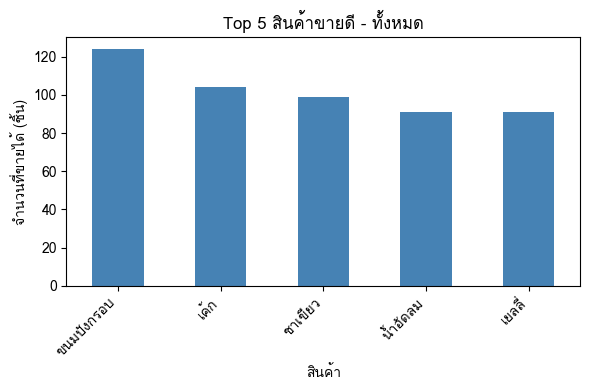


สรุปผลการวิเคราะห์ระบบร้านค้าปลีก
จำนวน Order ทั้งหมด : 300 Orders
ยอดขายสุทธิรวมทั้งหมด : 48,572.98 บาท
ส่วนลดจากคะแนนสมาชิกรวมทั้งหมด : 72.02 บาท

[Business Insight]
1. หมวดสินค้า ขนม มียอดขายสูงที่สุดที่ 19,812.49 บาท ร้านควรจัดพื้นที่วางสินค้าหมวดนี้ให้เด่นและสต็อกให้เพียงพอ
2. สินค้า ขนมปังกรอบ เป็นสินค้าที่ขายดีที่สุดโดยขายได้ 124 ชิ้น เหมาะเป็นสินค้าโปรโมชั่นดึงลูกค้า
3. วันที่ 2026-08-29 เป็นวันที่ยอดขายสูงสุดที่ 2,736.99 บาท ร้านอาจพิจารณาจัดพนักงานเพิ่มในวันลักษณะนี้
4. มี Order จากสมาชิกทั้งหมด 166 รายการ และระบบคะแนนสมาชิกช่วยให้ลูกค้าได้รับส่วนลดรวม 72.02 บาท สะท้อนว่าโปรแกรมสมาชิกมีผลต่อพฤติกรรมการซื้อจริง ไม่ใช่แค่ตัวเลขสะสมเฉย ๆ
5. จากข้อมูลจำลองทั้งหมด 300 Orders ร้านสามารถนำข้อมูลยอดขาย, สินค้าขายดี และวันที่คนเข้าร้านเยอะ มาใช้วางแผน Stock, กำลังคน และแคมเปญส่วนลดสมาชิกในอนาคตได้


In [13]:

# ============================================================
# PART 1: สร้างกราฟ
# ============================================================

# ------------------------------------------------------------
# 1. สัดส่วนยอดขายแยกตามหมวดสินค้า
# ------------------------------------------------------------

category_sales = pandas_category.set_index("category")["total_sales"]

plt.figure(figsize=(8, 5))
category_sales.plot(kind="pie", autopct="%1.1f%%", startangle=90)
plt.title("สัดส่วนยอดขายแยกตามหมวดสินค้า")
plt.ylabel("สัดส่วนยอดขาย")
plt.tight_layout()
plt.savefig("chart1.png")
plt.close()

# ------------------------------------------------------------
# 2. สินค้าที่ขายดีที่สุด 10 อันดับ (ตามจำนวนชิ้น)
# ------------------------------------------------------------

top10_products = (
    merged.groupby("product_name")["quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
top10_products.plot(kind="bar")
plt.title("สินค้าที่ขายดีที่สุด 10 อันดับ")
plt.xlabel("สินค้า")
plt.ylabel("จำนวนที่ขายได้ (ชิ้น)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("chart2.png")
plt.close()

# ------------------------------------------------------------
# 3. แนวโน้มยอดขายรายวัน
# ------------------------------------------------------------

daily_sales = (
    merged.assign(order_date=merged["order_time"].dt.date)
    .groupby("order_date")["net_sales_amount"]
    .sum()
)

plt.figure(figsize=(10, 5))
daily_sales.plot(kind="line", marker="o")
plt.title("แนวโน้มยอดขายรายวัน")
plt.xlabel("วันที่")
plt.ylabel("ยอดขายสุทธิ (บาท)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("chart3.png")
plt.close()

print("บันทึกกราฟทั้ง 3 ภาพสำเร็จ: chart1.png, chart2.png, chart3.png")


# ============================================================
# PART 2 (Bonus): Dashboard สรุปผลแบบโต้ตอบง่าย ๆ
# ============================================================

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    category_options = ["ทั้งหมด"] + sorted(merged["category"].unique().tolist())
    category_dropdown = widgets.Dropdown(
        options=category_options,
        value="ทั้งหมด",
        description="หมวดสินค้า:"
    )

    output_area = widgets.Output()

    def update_dashboard(change=None):
        with output_area:
            clear_output(wait=True)

            filtered = merged.copy()
            if category_dropdown.value != "ทั้งหมด":
                filtered = filtered[filtered["category"] == category_dropdown.value]

            summary = pd.Series({
                "total_orders": filtered["order_id"].nunique(),
                "total_quantity": filtered["quantity"].sum(),
                "total_sales": filtered["net_sales_amount"].sum(),
            })

            print(f"หมวดที่เลือก: {category_dropdown.value}")
            print(summary)

            top5 = (
                filtered.groupby("product_name")["quantity"]
                .sum()
                .sort_values(ascending=False)
                .head(5)
            )

            plt.figure(figsize=(6, 4))
            top5.plot(kind="bar", color="steelblue")
            plt.title(f"Top 5 สินค้าขายดี - {category_dropdown.value}")
            plt.xlabel("สินค้า")
            plt.ylabel("จำนวนที่ขายได้ (ชิ้น)")
            plt.xticks(rotation=45, ha="right")
            plt.tight_layout()
            plt.show()

    category_dropdown.observe(update_dashboard, names="value")

    display(category_dropdown, output_area)
    update_dashboard()

except ImportError:
    print(
        "ไม่พบ ipywidgets ในเครื่องนี้ — ถ้ารันใน Google Colab หรือ Jupyter "
        "ที่ลง ipywidgets แล้ว ส่วน Dashboard ด้านบนจะแสดง Dropdown ให้เลือกหมวด"
        "สินค้าและอัปเดตกราฟ/ตัวเลขสรุปแบบโต้ตอบได้ทันที"
    )


# ============================================================
# PART 3: สรุปผลการวิเคราะห์เชิงธุรกิจ
# ============================================================

best_category = pandas_category.iloc[0]
best_product_row = (
    merged.groupby("product_name")["quantity"].sum().sort_values(ascending=False)
)
best_product = best_product_row.idxmax()
best_product_qty = best_product_row.max()

best_day = daily_sales.idxmax()
best_day_sales = daily_sales.max()

total_sales_all = merged["net_sales_amount"].sum()
total_orders_all = merged["order_id"].nunique()
total_discount = merged["discount_amount"].sum()
member_orders = merged[merged["is_member"] == True]["order_id"].nunique()

print("\n" + "=" * 60)
print("สรุปผลการวิเคราะห์ระบบร้านค้าปลีก")
print("=" * 60)
print(f"จำนวน Order ทั้งหมด : {total_orders_all:,} Orders")
print(f"ยอดขายสุทธิรวมทั้งหมด : {total_sales_all:,.2f} บาท")
print(f"ส่วนลดจากคะแนนสมาชิกรวมทั้งหมด : {total_discount:,.2f} บาท")

print("\n[Business Insight]")
print(
    f"1. หมวดสินค้า {best_category['category']} มียอดขายสูงที่สุดที่ "
    f"{best_category['total_sales']:,.2f} บาท ร้านควรจัดพื้นที่วางสินค้าหมวดนี้"
    f"ให้เด่นและสต็อกให้เพียงพอ"
)
print(
    f"2. สินค้า {best_product} เป็นสินค้าที่ขายดีที่สุดโดยขายได้ "
    f"{best_product_qty:,} ชิ้น เหมาะเป็นสินค้าโปรโมชั่นดึงลูกค้า"
)
print(
    f"3. วันที่ {best_day} เป็นวันที่ยอดขายสูงสุดที่ {best_day_sales:,.2f} บาท "
    f"ร้านอาจพิจารณาจัดพนักงานเพิ่มในวันลักษณะนี้"
)
print(
    f"4. มี Order จากสมาชิกทั้งหมด {member_orders:,} รายการ และระบบคะแนน"
    f"สมาชิกช่วยให้ลูกค้าได้รับส่วนลดรวม {total_discount:,.2f} บาท "
    f"สะท้อนว่าโปรแกรมสมาชิกมีผลต่อพฤติกรรมการซื้อจริง ไม่ใช่แค่ตัวเลขสะสมเฉย ๆ"
)
print(
    f"5. จากข้อมูลจำลองทั้งหมด {total_orders_all:,} Orders ร้านสามารถนำข้อมูล"
    f"ยอดขาย, สินค้าขายดี และวันที่คนเข้าร้านเยอะ มาใช้วางแผน Stock, "
    f"กำลังคน และแคมเปญส่วนลดสมาชิกในอนาคตได้"
)
print("=" * 60)
